<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/reinforcement_learning/experiment_hidden_markov_model_forward_and_viterbi_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: DEFINE HMM
# ============================================

states = ["Sunny", "Rainy"]
observations = ["Walk", "Shop", "Clean"]

# Transition probabilities
A = {
    "Sunny": {"Sunny": 0.7, "Rainy": 0.3},
    "Rainy": {"Sunny": 0.4, "Rainy": 0.6}
}

# Emission probabilities
B = {
    "Sunny": {"Walk": 0.6, "Shop": 0.3, "Clean": 0.1},
    "Rainy": {"Walk": 0.1, "Shop": 0.4, "Clean": 0.5}
}

# Initial probabilities
pi = {"Sunny": 0.6, "Rainy": 0.4}

In [2]:
# ============================================
# LEVEL 2: FORWARD (ONE STEP)
# ============================================

obs = "Walk"

p = 0

for s in states:
    p += pi[s] * B[s][obs]

print("P(Observation):", p)

P(Observation): 0.4


In [3]:
obs_seq = ["Walk", "Shop", "Clean"]

alpha = pi.copy()

for obs in obs_seq:
    new_alpha = {}

    for s in states:
        total = 0
        for prev in states:
            total += alpha[prev] * A[prev][s]
        new_alpha[s] = total * B[s][obs]

    alpha = new_alpha

print("Final probabilities:", alpha)

Final probabilities: {'Sunny': 0.007542, 'Rainy': 0.02727}


In [4]:
# ============================================
# LEVEL 4: SIMPLE VITERBI STEP
# ============================================

obs = "Walk"

scores = {}

for s in states:
    scores[s] = pi[s] * B[s][obs]

print("Most likely state:", max(scores, key=scores.get))

Most likely state: Sunny


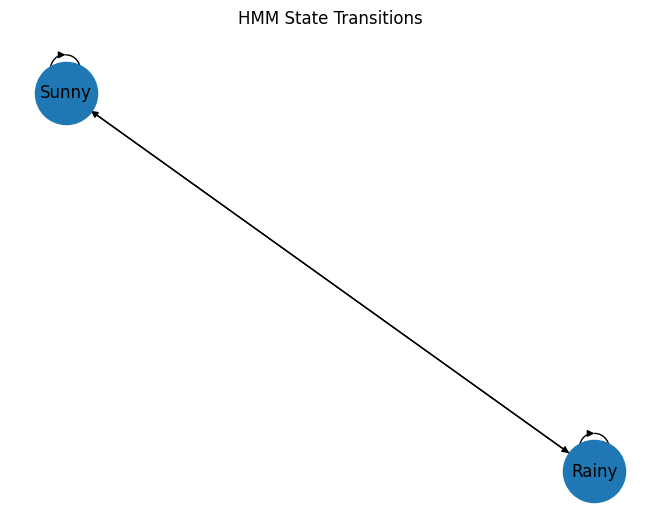

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Transitions
for s in states:
    for s2 in states:
        G.add_edge(s, s2)

nx.draw(G, with_labels=True, node_size=2000)
plt.title("HMM State Transitions")
plt.show()